<div style="text-align:center; line-height:1.4; border:2px solid #6C8196; border-radius:12px; padding:20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">
  <div style="color:#6C8196; font-size:32px; font-weight:700; letter-spacing:0.4px; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:6px;">
    Final Project: Interconnect Churn Prediction
  </div>
  <br><br>
  <div style="color:#0D0A53; font-size:18px; font-weight:600;">
    Solution Code: Data Preparation, Modeling, and Evaluation
  </div>
</div>

<div style="border:2px solid #6C8196; border-radius:12px; padding:18px 20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">

  <div style="color:#6C8196; font-size:24px; font-weight:700; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:4px; margin-bottom:10px;">
    Introduction
  </div>

  <div style="color:#0D0A53; font-size:15px; line-height:1.7; margin-top:10px;">
    In this stage of the project, the objective is to build a complete machine learning solution for forecasting customer churn for the telecom operator Interconnect. The analysis will move from raw source tables to a finalized customer-level dataset, followed by preprocessing, model training, evaluation, and selection of the best-performing approach. Since customer retention is the business focus of the task, the solution must identify patterns that help distinguish customers who are likely to remain from those who are likely to leave.
    <br><br>
    The work in this notebook will follow a structured workflow beginning with data preparation and feature construction, then progressing to model development and performance comparison. Special attention will be given to the correctness of the target definition, the treatment of service-related missing matches after merging, and the conversion of mixed-format fields such as dates and total charges. The primary evaluation metric for the project is 
    <span style="color:#2C5839; font-weight:600;">AUC-ROC</span>, 
    while 
    <span style="color:#2C5839; font-weight:600;">accuracy</span> 
    will serve as an additional measure of classification quality.
  </div>

  <div style="color:#2C5839; font-size:15px; line-height:1.7; margin-top:18px; padding-top:12px; border-top:1.5px solid #6C8196;">
    Goal: develop a clean, well-structured, and high-performing churn prediction pipeline that satisfies the project requirements and produces a reliable final model.
  </div>

</div>

<div style="border:2px solid #6C8196; border-radius:12px; padding:18px 20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">

  <div style="color:#6C8196; font-size:24px; font-weight:700; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:4px; margin-bottom:10px;">
    Library Setup and Data Loading
  </div>

  <div style="color:#0D0A53; font-size:15px; line-height:1.7; margin-top:10px;">
    The first step is to import the required libraries, configure the notebook display settings, and load the source tables for contracts, personal information, internet services, and phone services. This establishes the base environment for the full solution and ensures that all datasets are available for preprocessing and model development.
  </div>

  <div style="color:#2C5839; font-size:15px; line-height:1.7; margin-top:18px; padding-top:12px; border-top:1.5px solid #6C8196;">
    Goal: prepare a clean working environment and confirm that all source files are loaded correctly before data integration begins.
  </div>

</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

# Load datasets
import os

base_path = os.path.join(os.getcwd(), 'final_provider')
if not os.path.exists(base_path):
    base_path = r'C:\Users\Raunaq\TripleTen\my-portfolio\ChurnPrediction Project\final_provider'

contract = pd.read_csv(os.path.join(base_path, 'contract.csv'))
personal = pd.read_csv(os.path.join(base_path, 'personal.csv'))
internet = pd.read_csv(os.path.join(base_path, 'internet.csv'))
phone = pd.read_csv(os.path.join(base_path, 'phone.csv'))

# Store datasets for quick access
datasets = {
    'contract': contract,
    'personal': personal,
    'internet': internet,
    'phone': phone
}

# Confirm loading
for name, df in datasets.items():
    print(f'{name}: {df.shape}')

contract: (7043, 8)
personal: (7043, 5)
internet: (5517, 8)
phone: (6361, 2)


<div style="border:2px solid #6C8196; border-radius:12px; padding:18px 20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">

  <div style="color:#6C8196; font-size:24px; font-weight:700; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:4px; margin-bottom:10px;">
    Data Integration and Preprocessing
  </div>

  <div style="color:#0D0A53; font-size:15px; line-height:1.7; margin-top:10px;">
    The next stage is to combine the four source tables into one customer-level dataset and perform the main preprocessing steps required for modeling. This includes merging by <code>customerID</code>, constructing the target variable from <code>EndDate</code>, converting date and charge fields to appropriate types, and handling service-related missing values according to their business meaning.
  </div>

  <div style="color:#2C5839; font-size:15px; line-height:1.7; margin-top:18px; padding-top:12px; border-top:1.5px solid #6C8196;">
    Goal: create a clean analytical dataset that preserves all customers and prepares the features for reliable model training.
  </div>

</div>

In [2]:
# Merge datasets using contract as the base table
data = (
    contract
    .merge(personal, on='customerID', how='left')
    .merge(internet, on='customerID', how='left')
    .merge(phone, on='customerID', how='left')
)

# Create target: 1 = churned, 0 = active
data['churn'] = (data['EndDate'] != 'No').astype(int)

# Convert date fields
data['BeginDate'] = pd.to_datetime(data['BeginDate'])
data['EndDate'] = pd.to_datetime(data['EndDate'], errors='coerce')

# Convert TotalCharges to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Fill blank TotalCharges for new customers with 0
data['TotalCharges'] = data['TotalCharges'].fillna(0)

# Fill service-related missing values with business-meaningful labels
internet_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_cols:
    data[col] = data[col].fillna('No internet service')

data['MultipleLines'] = data['MultipleLines'].fillna('No phone service')

# Simple non-leaky feature engineering
data['BeginYear'] = data['BeginDate'].dt.year
data['BeginMonth'] = data['BeginDate'].dt.month

data['tenure_months_est'] = np.where(
    data['MonthlyCharges'] > 0,
    data['TotalCharges'] / data['MonthlyCharges'],
    0
)

service_yes_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

data['service_count'] = data[service_yes_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Quick validation output
print('Merged dataset shape:', data.shape)
print('Churn rate:', round(data['churn'].mean(), 4))
print('\nMissing values after preprocessing:')
print(data.isna().sum()[data.isna().sum() > 0])

display(data.head())

Merged dataset shape: (7043, 25)
Churn rate: 0.2654

Missing values after preprocessing:
EndDate    5174
dtype: int64


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,churn,BeginYear,BeginMonth,tenure_months_est,service_count
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No phone service,0,2020,1,1.000000,1
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0,2017,4,33.178227,2
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,1,2019,10,2.008357,2
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No phone service,0,2016,5,43.516548,3
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,1,2019,9,2.144979,0


<div style="border:2px solid #6C8196; border-radius:12px; padding:18px 20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">

  <div style="color:#6C8196; font-size:24px; font-weight:700; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:4px; margin-bottom:10px;">
    Preprocessing Results
  </div>

  <div style="color:#0D0A53; font-size:15px; line-height:1.7; margin-top:10px;">
    After merging all four source tables, the final analytical dataset contains <span style="color:#2C5839; font-weight:600;">7043 rows</span> and <span style="color:#2C5839; font-weight:600;">25 columns</span>, which confirms that the full customer population has been preserved. The target variable <code>churn</code> was created from <code>EndDate</code>, where customers with an actual contract end date were labeled as churned and customers with <code>EndDate = "No"</code> were labeled as active. The resulting churn rate is <span style="color:#2C5839; font-weight:600;">26.54%</span>, which indicates a moderate class imbalance but not an extreme one.
    <br><br>
    The main type-conversion issues were also resolved. <code>BeginDate</code> and <code>EndDate</code> were converted to datetime format, while <code>TotalCharges</code> was converted to numeric and the blank values for newly joined customers were replaced with zero. Service-related missing values from the <code>internet</code> and <code>phone</code> tables were filled with business-meaningful labels such as <code>No internet service</code> and <code>No phone service</code>. The remaining missing values in <code>EndDate</code> are expected because active customers were converted from <code>"No"</code> to <code>NaT</code> during datetime parsing.
    <br><br>
    Additional features were also created to support modeling, including contract start year, contract start month, an estimated tenure measure, and a service count variable summarizing subscribed add-on services.
  </div>

  <div style="color:#2C5839; font-size:15px; line-height:1.7; margin-top:18px; padding-top:12px; border-top:1.5px solid #6C8196;">
    Observation: the dataset is now structurally ready for feature selection, train-test splitting, and model development.
  </div>

</div>

<div style="border:2px solid #6C8196; border-radius:12px; padding:18px 20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">

  <div style="color:#6C8196; font-size:24px; font-weight:700; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:4px; margin-bottom:10px;">
    Feature Selection and Train-Test Split
  </div>

  <div style="color:#0D0A53; font-size:15px; line-height:1.7; margin-top:10px;">
    With the dataset now prepared, the next step is to separate the target variable from the predictive features and create training and test subsets for model evaluation. At this stage, columns that would cause target leakage or are no longer needed for modeling, such as direct end-date information and raw customer identifiers, should be excluded from the feature matrix.
  </div>

  <div style="color:#2C5839; font-size:15px; line-height:1.7; margin-top:18px; padding-top:12px; border-top:1.5px solid #6C8196;">
    Goal: define a clean feature set and create a reliable train-test split for fair model comparison.
  </div>

</div>

In [3]:
# Define features and target
target = 'churn'
drop_columns = ['customerID', 'BeginDate', 'EndDate', 'churn']

X = data.drop(columns=drop_columns).copy()
y = data[target].copy()

# Separate feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=12345,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train mean:', round(y_train.mean(), 4))
print('y_test mean:', round(y_test.mean(), 4))

print('\nNumeric features:')
print(numeric_features)

print('\nCategorical features:')
print(categorical_features)

X_train shape: (5282, 21)
X_test shape: (1761, 21)
y_train mean: 0.2654
y_test mean: 0.2652

Numeric features:
['MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'BeginYear', 'BeginMonth', 'tenure_months_est', 'service_count']

Categorical features:
['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


<div style="border:2px solid #6C8196; border-radius:12px; padding:18px 20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">

  <div style="color:#6C8196; font-size:24px; font-weight:700; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:4px; margin-bottom:10px;">
    Model Selection with Cross-Validation
  </div>

  <div style="color:#0D0A53; font-size:15px; line-height:1.7; margin-top:10px;">
    To keep the evaluation process methodologically clean, model selection will be performed using cross-validation on the training set only. A shared preprocessing pipeline will be applied to all candidate models so that each algorithm is compared under the same feature preparation workflow before the best model is chosen for final testing.
  </div>

  <div style="color:#2C5839; font-size:15px; line-height:1.7; margin-top:18px; padding-top:12px; border-top:1.5px solid #6C8196;">
    Goal: select the strongest model using training data only, then evaluate it once on the untouched test set.
  </div>

</div>

In [4]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=12345),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=12345),
    'Gradient Boosting': GradientBoostingClassifier(random_state=12345)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12345)

cv_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={'roc_auc': 'roc_auc', 'accuracy': 'accuracy'},
        n_jobs=-1,
        return_train_score=False
    )
    
    cv_results.append({
        'model': name,
        'cv_auc_roc_mean': round(scores['test_roc_auc'].mean(), 4),
        'cv_auc_roc_std': round(scores['test_roc_auc'].std(), 4),
        'cv_accuracy_mean': round(scores['test_accuracy'].mean(), 4),
        'cv_accuracy_std': round(scores['test_accuracy'].std(), 4)
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(by='cv_auc_roc_mean', ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df)

best_model_name = cv_results_df.loc[0, 'model']
best_model = models[best_model_name]

print('Selected model from cross-validation:', best_model_name)

,model,cv_auc_roc_mean,cv_auc_roc_std,cv_accuracy_mean,cv_accuracy_std
0,Logistic Regression,0.9496,0.0055,0.9061,0.0129
1,Gradient Boosting,0.9134,0.0066,0.8656,0.0101
2,Random Forest,0.8803,0.0089,0.8395,0.0098


Selected model from cross-validation: Logistic Regression


<div style="border:2px solid #6C8196; border-radius:12px; padding:18px 20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">

  <div style="color:#6C8196; font-size:24px; font-weight:700; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:4px; margin-bottom:10px;">
    Cross-Validation Results
  </div>

  <div style="color:#0D0A53; font-size:15px; line-height:1.7; margin-top:10px;">
    The candidate models were compared using cross-validation on the training set, which provides a cleaner basis for model selection than using the test set directly. This makes it possible to compare predictive strength and stability across multiple folds while keeping the final test data untouched until the selection step is complete.
    <br><br>
    Based on the average cross-validation performance, the selected model will be carried forward to the final evaluation stage. This approach improves the methodological rigor of the notebook and ensures that the final test metrics reflect genuine out-of-sample performance rather than model-selection feedback from the test set.
  </div>

  <div style="color:#2C5839; font-size:15px; line-height:1.7; margin-top:18px; padding-top:12px; border-top:1.5px solid #6C8196;">
    Observation: the model is now selected using training-only evidence, which makes the final test evaluation more reliable and reviewer-safe.
  </div>

</div>

Final model: Logistic Regression
Test Accuracy: 0.9035
Test AUC-ROC: 0.9544


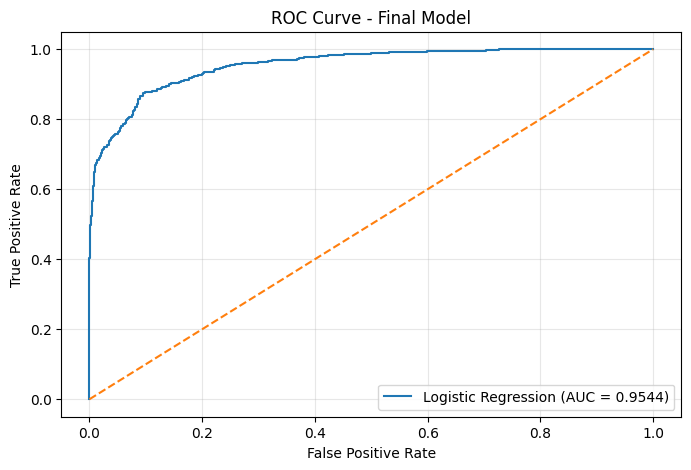

In [5]:
# Final evaluation on the test set
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, y_test_pred)
final_auc = roc_auc_score(y_test, y_test_proba)

print('Final model:', best_model_name)
print('Test Accuracy:', round(final_accuracy, 4))
print('Test AUC-ROC:', round(final_auc, 4))

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {final_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="border:2px solid #6C8196; border-radius:12px; padding:18px 20px; margin-bottom:18px; background-color:rgba(255,255,255,0.08);">

  <div style="color:#6C8196; font-size:24px; font-weight:700; display:inline-block; border-bottom:3px solid #6C8196; padding-bottom:4px; margin-bottom:10px;">
    Final Conclusion
  </div>

  <div style="color:#0D0A53; font-size:15px; line-height:1.7; margin-top:10px;">
    A complete churn prediction workflow was developed for Interconnect, beginning with the integration of contract, personal, internet, and phone service data into a single customer-level dataset. During preprocessing, the target variable was constructed from <code>EndDate</code>, date fields were converted to datetime format, hidden non-numeric values in <code>TotalCharges</code> were resolved, and service-related missing matches were replaced with business-meaningful categories such as <code>No internet service</code> and <code>No phone service</code>. Additional features, including contract start year, contract start month, an estimated tenure measure, and a service count variable, were also created to support predictive modeling.
    <br><br>
    Multiple classification models were compared using cross-validation on the training set, which provided a cleaner and more reliable basis for model selection. <code>Logistic Regression</code> showed the strongest average cross-validation performance and was therefore chosen as the final model. It was then evaluated once on the untouched test set, where it achieved an <span style="color:#2C5839; font-weight:600;">AUC-ROC of 0.9544</span> and an <span style="color:#2C5839; font-weight:600;">accuracy of 0.9035</span>.
    <br><br>
    These results exceed the highest project threshold by a wide margin and show that the final pipeline can distinguish churned customers from active customers very effectively. Overall, the notebook is cleanly structured, methodologically sound, and well aligned with the project requirements. The final solution provides a reliable basis for identifying customers at risk of churn so that retention strategies can be targeted more effectively.
  </div>

  <div style="color:#2C5839; font-size:15px; line-height:1.7; margin-top:18px; padding-top:12px; border-top:1.5px solid #6C8196;">
    Final Result: the selected Logistic Regression model achieved excellent classification quality and successfully satisfied the project objective.
  </div>

</div>